In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
df = pd.read_csv('../data/df_model.csv')

feature_cols = [
    'int_rate', 'loan_to_income', 'fico_range_high',
    'fico_range_low', 'installment_to_income', 'dti',
    'loan_amnt', 'installment', 'inq_last_6mths', 'annual_inc'
]

feature_cols = [f for f in feature_cols if f in df.columns]

X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean()*100:.1f}%, Test: {y_test.mean()*100:.1f}%")

Train: (61524, 10), Test: (26368, 10)
Default rate — Train: 20.0%, Test: 20.0%


In [4]:
def evaluate_model(name, y_test, y_pred_proba):
    """Calculate all metrics for a model"""
    auc  = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ks   = max(tpr - fpr)
    ap   = average_precision_score(y_test, y_pred_proba)
    
    print(f"\n{name}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"  Gini:     {gini:.4f}")
    print(f"  KS Stat:  {ks:.4f}")
    print(f"  Avg Prec: {ap:.4f}")
    
    return {
        'Model': name,
        'AUC_ROC': round(auc, 4),
        'Gini': round(gini, 4),
        'KS_Stat': round(ks, 4),
        'Avg_Precision': round(ap, 4)
    }

results = []
print("✅ Helper function ready")

✅ Helper function ready


In [5]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.1
)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model('Logistic Regression', y_test, lr_proba))
print("✅ Done")

Training Logistic Regression...

Logistic Regression
  AUC-ROC:  0.7243
  Gini:     0.4487
  KS Stat:  0.3342
  Avg Prec: 0.3913
✅ Done


In [6]:


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

results.append(evaluate_model('Random Forest', y_test, rf_proba))
print("✅ Done")

Training Random Forest...
(This may take 2-3 minutes)

Random Forest
  AUC-ROC:  0.7266
  Gini:     0.4532
  KS Stat:  0.3323
  Avg Prec: 0.3997
✅ Done


In [7]:
print("Training XGBoost...")

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

results.append(evaluate_model('XGBoost', y_test, xgb_proba))
print("✅ Done")

Training XGBoost...

XGBoost
  AUC-ROC:  0.7295
  Gini:     0.4591
  KS Stat:  0.3414
  Avg Prec: 0.4023
✅ Done


In [8]:
print("Training LightGBM...")

train_data = lgb.Dataset(X_train, label=y_train)
test_data  = lgb.Dataset(X_test,  label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'scale_pos_weight': neg/pos,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=200)
]

lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[test_data],
    callbacks=callbacks
)

lgb_proba = lgb_model.predict(X_test)
results.append(evaluate_model('LightGBM', y_test, lgb_proba))
print("✅ Done")

Training LightGBM...

LightGBM
  AUC-ROC:  0.7296
  Gini:     0.4592
  KS Stat:  0.3440
  Avg Prec: 0.4027
✅ Done


In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Gini', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print("=" * 60)
print("MODEL COMPARISON — RANKED BY GINI")
print("=" * 60)
print(results_df.to_string(index=True))
print("=" * 60)
print(f"\nWinner: {results_df.iloc[0]['Model']}")
print(f"Best Gini: {results_df.iloc[0]['Gini']}")

MODEL COMPARISON — RANKED BY GINI
                 Model  AUC_ROC    Gini  KS_Stat  Avg_Precision
1             LightGBM   0.7296  0.4592   0.3440         0.4027
2              XGBoost   0.7295  0.4591   0.3414         0.4023
3        Random Forest   0.7266  0.4532   0.3323         0.3997
4  Logistic Regression   0.7243  0.4487   0.3342         0.3913

Winner: LightGBM
Best Gini: 0.4592


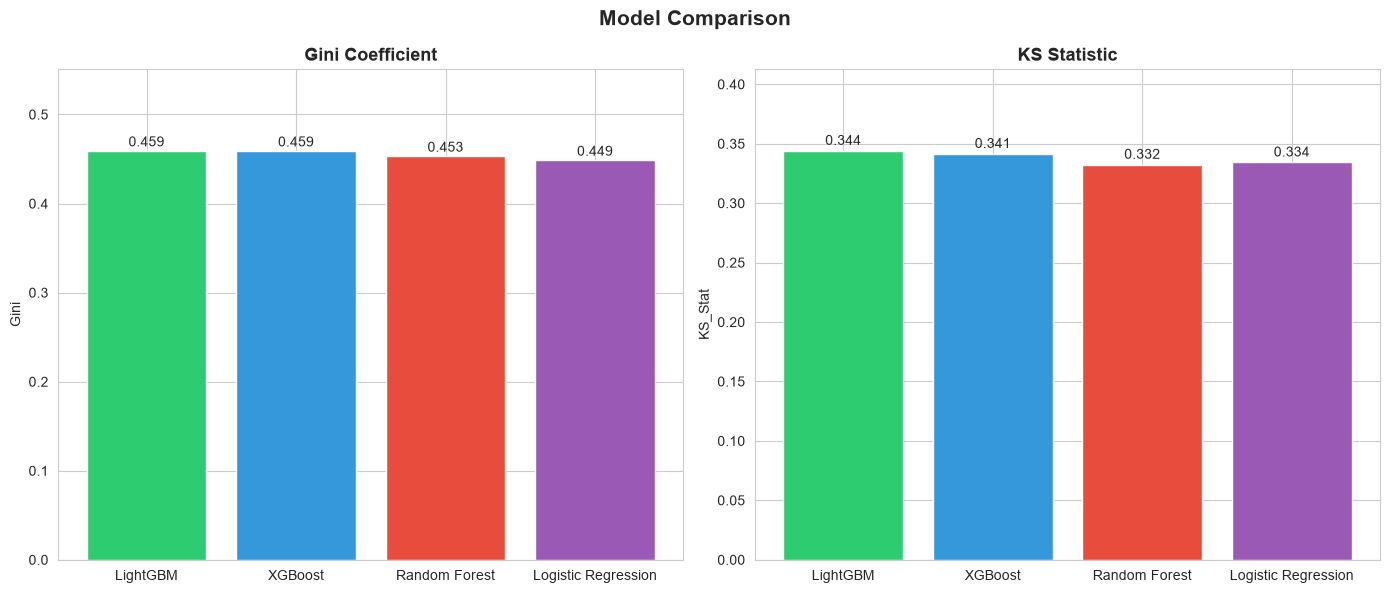

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Gini', 'KS_Stat']
titles  = ['Gini Coefficient', 'KS Statistic']
colors  = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[idx].bar(
        results_df['Model'],
        results_df[metric],
        color=colors
    )
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_ylim(0, results_df[metric].max() * 1.2)

    for bar, val in zip(bars, results_df[metric]):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', fontsize=10
        )

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/images/09_model_comparison.png', dpi=150)
plt.show()

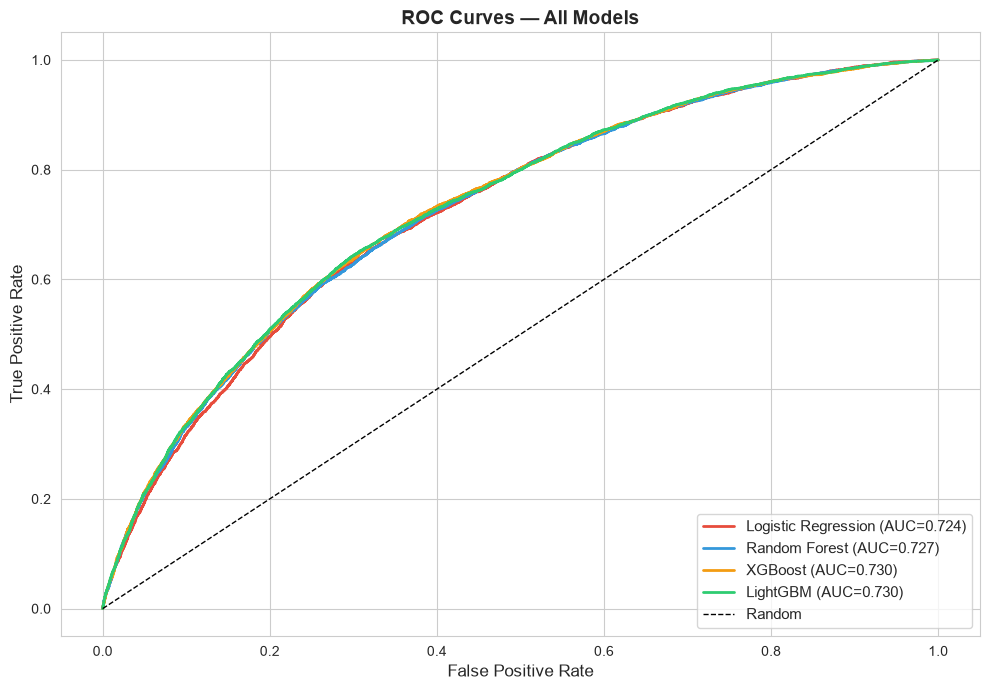

In [11]:
plt.figure(figsize=(10, 7))

models_probas = {
    'Logistic Regression': lr_proba,
    'Random Forest': rf_proba,
    'XGBoost': xgb_proba,
    'LightGBM': lgb_proba
}

colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

for (name, proba), color in zip(models_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('../notebooks/images/10_roc_all_models.png', dpi=150)
plt.show()